In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import copy

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
TRAIN_DIR = '/content/drive/MyDrive/INTERNSHIP/PlantVillage/train'
VAL_DIR   = '/content/drive/MyDrive/INTERNSHIP/PlantVillage/val'

In [5]:
# define transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
# load datasets
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(root=VAL_DIR, transform=val_transforms)

class_names = train_dataset.classes
print("number of classes:", len(class_names))

number of classes: 38


In [7]:
# create weighted sampler for class imbalance
targets = train_dataset.targets
class_counts = np.bincount(targets)

class_weights = 1. / class_counts
sample_weights = class_weights[targets]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [8]:
# create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    sampler=sampler,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [9]:
# define mlp model
class MLP(nn.Module):
    def __init__(self, num_classes):
        super(MLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(3*224*224, 512)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [10]:
# define cnn model
class CNN(nn.Module):
    def __init__(self, num_classes):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(64*56*56, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [11]:
# define training function
def train_and_validate(model, train_loader, val_loader, optimizer, criterion, device, epochs=5):

    train_losses = []
    val_losses = []
    val_accuracies = []

    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):

        model.train()
        running_loss = 0.0

        for images, labels in tqdm(train_loader, desc=f"training epoch {epoch+1}"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc="validating"):
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = running_loss / len(val_loader.dataset)
        epoch_val_acc  = correct / total

        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)

        print(f"\nepoch [{epoch+1}/{epochs}]")
        print(f"train loss: {epoch_train_loss:.4f}")
        print(f"val loss: {epoch_val_loss:.4f}")
        print(f"val accuracy: {epoch_val_acc:.4f}\n")

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_wts = copy.deepcopy(model.state_dict())

    return train_losses, val_losses, val_accuracies, best_model_wts

In [12]:
# initialize loss function
criterion = nn.CrossEntropyLoss()

In [13]:
# train mlp model
mlp_model = MLP(len(class_names)).to(device)
optimizer_mlp = optim.Adam(mlp_model.parameters(), lr=0.001)

mlp_train_losses, mlp_val_losses, mlp_val_accuracies, _ = train_and_validate(
    mlp_model, train_loader, val_loader,
    optimizer_mlp, criterion, device,
    epochs=5
)

validating: 100%|██████████| 340/340 [33:23<00:00,  5.89s/it]



epoch [1/5]
train loss: 5.4617
val loss: 12.6420
val accuracy: 0.2696



validating: 100%|██████████| 340/340 [00:59<00:00,  5.69it/s]



epoch [2/5]
train loss: 4.1329
val loss: 12.2238
val accuracy: 0.3120



validating: 100%|██████████| 340/340 [00:59<00:00,  5.71it/s]



epoch [3/5]
train loss: 4.0814
val loss: 22.9068
val accuracy: 0.2904



validating: 100%|██████████| 340/340 [01:11<00:00,  4.78it/s]



epoch [4/5]
train loss: 4.2959
val loss: 38.6242
val accuracy: 0.2919



validating: 100%|██████████| 340/340 [01:05<00:00,  5.15it/s]


epoch [5/5]
train loss: 3.8339
val loss: 15.1362
val accuracy: 0.3025



In [14]:
# train cnn model
cnn_model = CNN(len(class_names)).to(device)
optimizer_cnn = optim.Adam(cnn_model.parameters(), lr=0.001)

cnn_train_losses, cnn_val_losses, cnn_val_accuracies, best_cnn_wts = train_and_validate(
    cnn_model, train_loader, val_loader,
    optimizer_cnn, criterion, device,
    epochs=5
)

validating: 100%|██████████| 340/340 [01:01<00:00,  5.50it/s]



epoch [1/5]
train loss: 1.5091
val loss: 0.8588
val accuracy: 0.7312



validating: 100%|██████████| 340/340 [01:01<00:00,  5.53it/s]



epoch [2/5]
train loss: 0.6357
val loss: 0.6451
val accuracy: 0.7970



validating: 100%|██████████| 340/340 [01:03<00:00,  5.32it/s]



epoch [3/5]
train loss: 0.4104
val loss: 0.5224
val accuracy: 0.8403



validating: 100%|██████████| 340/340 [01:14<00:00,  4.58it/s]



epoch [4/5]
train loss: 0.3118
val loss: 0.4287
val accuracy: 0.8697



validating: 100%|██████████| 340/340 [01:04<00:00,  5.28it/s]


epoch [5/5]
train loss: 0.2673
val loss: 0.3405
val accuracy: 0.8986



In [15]:
# save best cnn model with metadata
save_path = "/content/drive/MyDrive/INTERNSHIP/best_cnn_model.pth"

torch.save({
    "model_state_dict": best_cnn_wts,
    "class_names": class_names,
    "input_size": (3, 224, 224)
}, save_path)

print("best cnn model saved at:", save_path)

best cnn model saved at: /content/drive/MyDrive/INTERNSHIP/best_cnn_model.pth


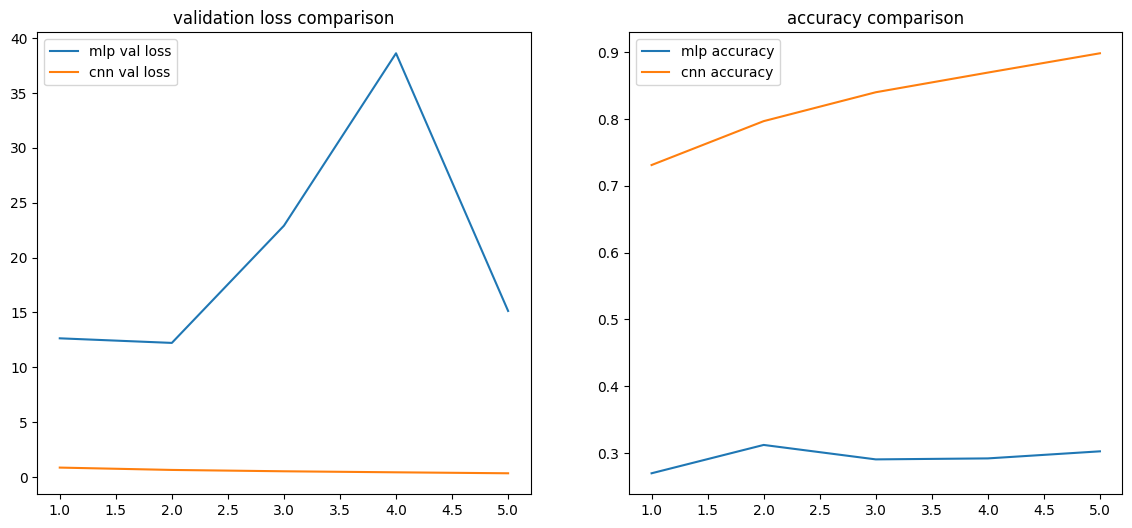

In [16]:
# plot comparison graphs
epochs = range(1, 6)

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.plot(epochs, mlp_val_losses, label="mlp val loss")
plt.plot(epochs, cnn_val_losses, label="cnn val loss")
plt.legend()
plt.title("validation loss comparison")

plt.subplot(1,2,2)
plt.plot(epochs, mlp_val_accuracies, label="mlp accuracy")
plt.plot(epochs, cnn_val_accuracies, label="cnn accuracy")
plt.legend()
plt.title("accuracy comparison")

plt.show()

In [17]:
# create comparison table between mlp and cnn models
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

comparison_df = pd.DataFrame({
    "model": ["mlp (5 epochs)", "cnn (5 epochs)"],
    "final train loss": [
        mlp_train_losses[-1],
        cnn_train_losses[-1]
    ],
    "best val loss": [
        min(mlp_val_losses),
        min(cnn_val_losses)
    ],
    "best val accuracy": [
        max(mlp_val_accuracies),
        max(cnn_val_accuracies)
    ],
    "total parameters": [
        count_parameters(mlp_model),
        count_parameters(cnn_model)
    ]
})

print("model comparison:")
display(comparison_df)

model comparison:


,model,final train loss,best val loss,best val accuracy,total parameters
0,mlp (5 epochs),3.833914,12.223779,0.312034,77090342
1,cnn (5 epochs),0.267302,0.340494,0.898628,51409638


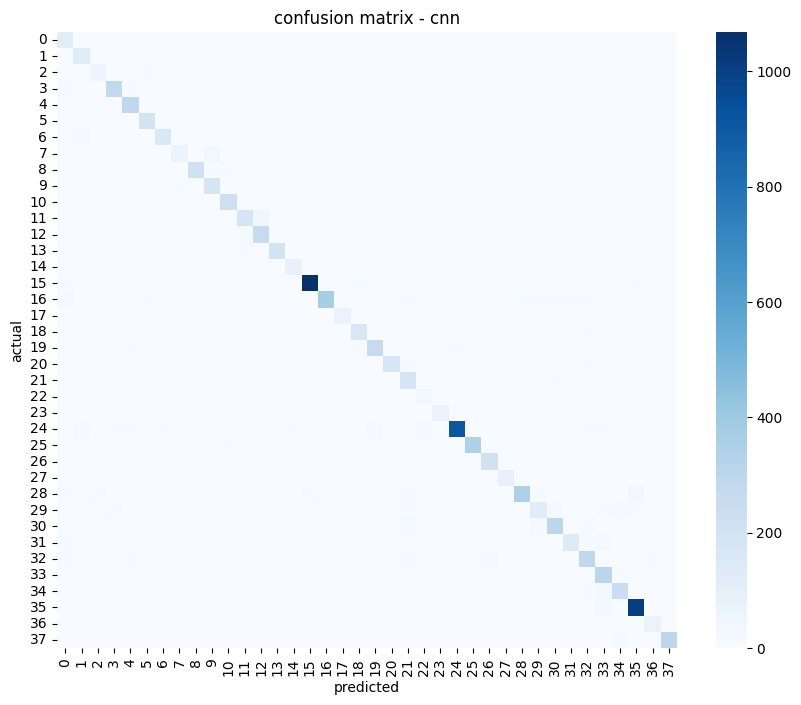

In [18]:
# plot confusion matrix for cnn model
from sklearn.metrics import confusion_matrix
import seaborn as sns

best_model = CNN(len(class_names)).to(device)
best_model.load_state_dict(best_cnn_wts)
best_model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = best_model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("confusion matrix - cnn")
plt.xlabel("predicted")
plt.ylabel("actual")
plt.show()